# Trailing-plate force balance in a free subduction model (Fluidity)

This notebook diagnoses the **vertically integrated horizontal force balance** in the Cerpa et al. 2-D Fluidity subduction models — free subduction, no kinematic boundary conditions, a full plate from ridge to trench.

**Position in the project.** One suite in the trench-pull analysis collection (one repository per published numerical model). Model description and raw-field disambiguation: [`MODEL.md`](../MODEL.md). Notation: the umbrella project's `SYMBOLOGY.md`. The forced-model counterpart (MDOODZ, no ridge — hones in on the trench-pull term) is analysed in `trench_pull_mdoodz`.

**The story in one paragraph.** Everything rests on the balance $\Delta N_D - \Delta\mathrm{GPE}^* + F_B = 0$, and on one discipline: **retain the full vertical normal stress** $\sigma_{zz}$ — for a non-isostatic column the lithostatic pressure is a fiction that does not maintain static equilibrium, and the model returns $\sigma_{zz}$ directly. Because this model carries the whole plate, the full variation of $\Delta\bar\sigma_{zz}$ shows both contributions at once: the trench's non-isostatic pressure deficit (**trench pull**) and the isostatic cooling topography (**ridge push**). Together they constitute the pressure gradient that drives the trailing plate, and they partition cleanly — non-overlapping components sharing one reference column, the first isostatic column $x_I$. Equilibration of the columns below the strong lithosphere is good but not perfect: a sub-plate pressure gradient exists (§8C), though it is far smaller than the topographic gradients. The normal-stress-difference resultant $N_D$ at the trench is neutral-to-negative — *resisting* — through most of the run: the opposite of the textbook slab-pull picture. Basal drag also resists, and on the wavelength of the trench topography it is always second order.

**Notebook structure.**

1. Setup & imports
2. Configuration — model, timestep, grid, **mirror flag**
3. Helper functions — field extraction, trench pickers, **mirror operator**
4. Build the regular grid, extract fields, **apply x-mirror**
5. Trench / ridge identification
6. **The headline — $\Delta\mathrm{GPE}^*$ tracks topography**
7. Vertically integrated traction quantities
8. Trench topography — shear-stress support (8B column profiles, 8C sub-plate gradient)
9. Force-balance plots (9.2 incremental form, 9.3 absolute $N_D$)
10. Time evolution — loop over timesteps

> Note that the model is mirrored along the x-axis so that subduction matches the earlier MDOODZ model analysis  used
> in the trench_pull_mdoodz notebooks: subducting plate on the **right**, plate
> velocity negative (leftward) toward the trench, slab dipping toward the left.
> Coordinate convention is unchanged: x rightward positive, z downward positive.


## 1. Setup & imports

Numerical libraries, PyVista for VTK/PVTU I/O, and minor configuration to silence VTK chatter.


In [1]:
#import pyvista as pv
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
try:
    from numpy import trapezoid as trapz
except ImportError:  # numpy < 2.0
    from numpy import trapz
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter
import pyvista as pv
import warnings
import logging
from pathlib import Path

# 1) Redirect VTK C++ error output
pv.set_error_output_file(Path("/tmp/vtk_errors.log"))

# 2) Silence Python logging coming from VTK / PyVista
logging.getLogger("pyvista").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

# 3) Silence the Python UserWarning layer
warnings.filterwarnings(
    "ignore",
    message="The VTK reader .*vtkXMLPUnstructuredGridReader.*"
)

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})
import pyvista as pv
#import cmcrameri as cmc

## 2. Configuration

Centralised configuration. Change `MODEL_KEY` to swap between reference models, and `TIMESTEP_INDEX` to load a different snapshot. Grid parameters control the regular grid the PVTU is interpolated onto for vertical integration; both the single-timestep analysis (§4) and the time loop (§9) use these same values.


In [2]:
# === Model selection =========================================================
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'   # 'STD' or 'WAL'
TIMESTEP_INDEX = 10      # 0-indexed; negative values count from the end (-1 = last)
SECONDS_PER_YEAR = 31_557_600.0   # used for NormalSP::Time -> years conversion

# === Regular-grid parameters (metres) ========================================
DX        = 200.0        # horizontal & vertical grid spacing on the analysis grid
Z_MAX     = 75_000.0    # depth extent
Y_SURFACE = 2_900_000.0  # VTK y-coordinate of the model's free surface

# === Mirror flag =============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: x_trench + SEAWARD_SIGN * offset_metres

# === Resolved paths ==========================================================
fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']

pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} timesteps in {fbase}")
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


# === Canonical analysis defaults =============================================
# Promoted here from various downstream cells.  Override locally only if a
# specific figure needs a different value, and document the reason inline.
INTEGRATION_DEPTH_KM = 75              # Depth [km] for vertical σ_zz integrals
SMOOTHWIN            = 10               # ± grid columns averaged around picked columns
TRENCH_REF_HW_KM     = 5                # half-width [km]: uniform ±5 km suite window (conventions §4.1)
WIN_T                = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))   # in grid points
RHO_W                = 0.0              # no water above the surface (Cerpa setup)
rho_m, g             = 3300.0, 9.8      # mantle reference density [kg/m³] and gravity [m/s²]

# === Plot defaults ===========================================================
DEPTH_LIM = (INTEGRATION_DEPTH_KM, 0)   # default ylim for depth panels (positive down on top)

# === Output dir ==============================================================
figures_dir = Path("../figures"); figures_dir.mkdir(exist_ok=True)


Model 'WAL': 41 timesteps in /Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


In [3]:
#Y_SURFACE
#x_trench

Pick a single timestep for the analysis below.

In [4]:
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Loading timestep {i}: {ff.split('/')[-1]}")
vtk_data = pv.read(ff);


Loading timestep 10: subduction_with_LM_10.pvtu


## 3. Helper functions

- `get_field(name)` — reshapes a PyVista point-data array onto the regular grid and masks invalid samples.
- `find_trench_x(...)` — simple trench picker: coarse pressure-minimum guess plus refined `vx` zero-crossing.
- `pick_trench_3step(...)` — three-stage picker (pressure → velocity → directional pressure search). More robust for snapshots where the surface pressure has multiple local minima; this is the picker used by the time loop.


In [5]:
import sys, os
_r = os.getcwd()
while not os.path.isdir(os.path.join(_r, 'scripts')) and os.path.dirname(_r) != _r:
    _r = os.path.dirname(_r)
if os.path.join(_r, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(_r, 'scripts'))
from fluidity_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    norm_TR,
    load_records,
)


## 4. Build grid and extract fields (single timestep)

Construct a uniform cell-centred grid over `[x_min, x_max] × [0, Z_MAX]` and sample the PVTU onto it. Stress, pressure, temperature, and velocity are extracted as 2D arrays indexed `[z, x]` with depth positive downward.


In [6]:
# === Read PVTU and stash named point-data arrays =============================
vtk_data = pv.read(ff)

vtk_data.point_data["p"]   = vtk_data["NormalSP::Pressure"]
vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
vtk_data.point_data["txz"] = -vtk_data["NormalSP::Stress"][:, 1]
vtk_data.point_data["T"]   = vtk_data["NormalSP::Temperature"]
vtk_data.point_data["fs"]  = vtk_data["NormalSP::FreeSurface"]  # surface deflection (m)

vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10  # m/s -> m/yr
vtk_data.point_data["vx"] = vel[:, 0]
vtk_data.point_data["vy"] = vel[:, 1]

# === Define a regular cell-centred analysis grid =============================
x_min, x_max, _, _, _, _ = vtk_data.bounds

nx = int((x_max - x_min) / DX)
nz = int(Z_MAX / DX)

x = x_min + (np.arange(nx) + 0.5) * DX     # metres
z = (np.arange(nz) + 0.5) * DX              # depth, metres (positive down)

X, Z = np.meshgrid(x, z, indexing="xy")
Y    = Y_SURFACE - Z                        # depth -> VTK y

grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))

# === Interpolate VTK fields onto the regular grid ============================
interp = grid.sample(vtk_data)

nx_pv, nz_pv, _ = interp.dimensions
valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)
get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

# === Final canonical-form arrays =============================================
# field[z_index, x_index] lives at (x[x_index], z[z_index])
p   = get_field("p")
txx = get_field("txx")
tzz = get_field("tzz")
txz = get_field("txz")
T   = get_field("T")
vx  = get_field("vx")
vz  = -get_field("vy")            # positive downward
fs  = get_field("fs")             # free-surface deflection (top row only)

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print("(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)")

print("x (m):", x[0], "->", x[-1], "  nx =", len(x))
print("z (m):", z[0], "->", z[-1], "  nz =", len(z))
print("p.shape =", p.shape)




(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
x (m): 100.0 -> 7999700.0   nx = 39999
z (m): 100.0 -> 74900.0   nz = 375
p.shape = (375, 39999)


In [7]:
#fs.shape, p.shape

## 5. Trench / Ridge identification

Two pickers are exercised here. The simple one (`find_trench_x`) gives a coarse anchor; the 3-step picker (`pick_trench_3step`) refines it via a directional pressure search on the subducting-plate side.

*This remains the most fragile step in the workflow — see the visual check at the end of the section if a pick looks wrong.*


In [8]:
#surface_p = p[10, :]          # surface row
#ploc = x[np.argmin(surface_p)]

In [9]:
#x_trench, info = find_trench_x(x, z, p, vx, z_pick_m=0, window_km=800, smooth_km=1)
#print("trench_x (km):", x_trench/1000, "method:", info["method"])

In [10]:
x_trench, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000,
    Wp1_km=1000,
    Wv_km=800,
    Wp3_km=800,
    smooth_km=40,
    subducting_side=SUBDUCTING_SIDE,
)

tindx = int(np.argmin(np.abs(x - x_trench)))

rloc, rindx = find_ridge_x(                                                                                                                                                                  
      x, fs[0, :], x_trench,                                    
      seaward_sign=SEAWARD_SIGN,                                                                                                                                                                         
      buffer_km=200, smooth_km=50,
  )


print("Trench (km):", x_trench / 1000)
print("Ridge (km):", rloc / 1000)
print("Velocity anchor (km):", info["x_v"] / 1000)
print("Methods:", info["vx_method"], info["p_method"])

Trench (km): 4440.5
Ridge (km): 7677.1
Velocity anchor (km): 4374.34664424877
Methods: zero_cross_rightmost local_min_windowed


(3940.5, 7727.1)

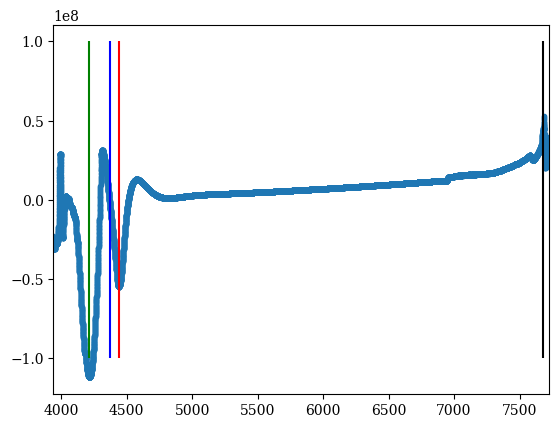

In [11]:
fig, ax = plt.subplots()

ax.plot(x*1e-3 , p[0,:], marker=".")

ax.vlines(x_trench*1e-3, 1e8, -1e8, color='r')
ax.vlines(rloc*1e-3, 1e8, -1e8, color='k')

ax.vlines(info["x_p0"]*1e-3, 1e8, -1e8, color='g')
ax.vlines(info["x_v"]*1e-3, 1e8, -1e8, color='b')


ax.set_xlim(x_trench*1e-3 - 500, rloc*1e-3 + 50)


In [12]:
xkm_rel = (x - x_trench) * 1e-3
t_yr    = float(np.asarray(vtk_data["NormalSP::Time"]).flat[0]) / SECONDS_PER_YEAR

## 6. The headline — $\Delta\mathrm{GPE}^*$ tracks topography

The figure this notebook exists to produce, shown before the decomposition that explains it. $\Delta\mathrm{GPE}^*(x)$ — the between-column difference of the vertical normal stress integral — and the surface topography, each linearly rescaled so the trench is 0 and the ridge is 1, plotted on the same axis from $x_T$ to $x_R$.

The point: this net-force quantity is a very close proxy to topography, and it carries **both** signals — the trench's non-isostatic deflection and the isostatic cooling topography out to the ridge. Because $\Delta\bar\sigma_{zz}$ enters the horizontal force balance as a component of pressure, what this curve *is* is a pressure gradient: the net driving force on the trailing plate. The rest of the notebook establishes that reading — the full balance (§9) shows the other resultants resist through most of the history, so the drive comes entirely from this topographic pressure gradient, and §8 and the time-evolution notebook show how it partitions into the trench part and the isostatic-cooling (ridge push) part against their shared reference column, $x_I$.

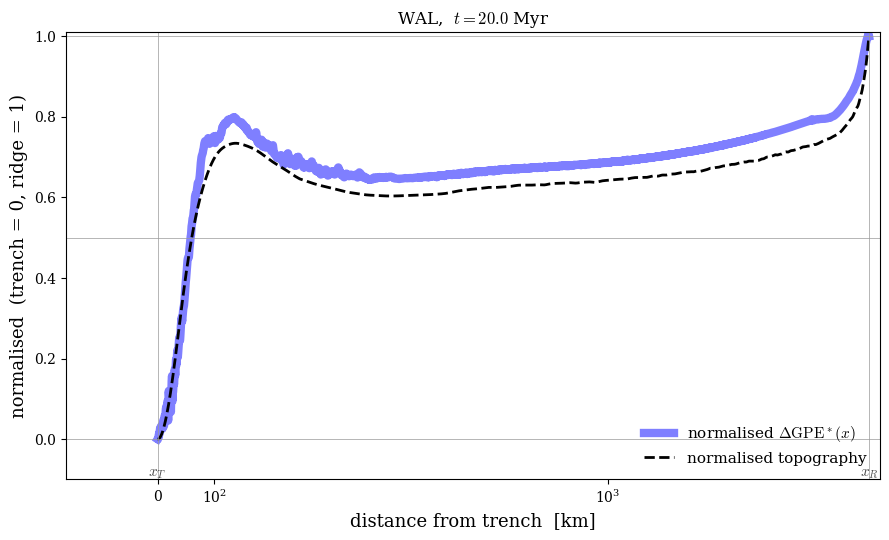

In [13]:
# Both \Delta\mathrm{GPE}^*(x) and topography(x) plotted on the same axis, each linearly
# rescaled so that
#   value(x_T) = 0   (trench)
#   value(x_R) = 1   (ridge)
#
# Lets you eyeball how closely the GPE column-integral tracks surface
# elevation as you move from trench to ridge.

# --- Locate the ridge ----------------------------------------------------
ridge_loc, ridge_indx = find_ridge_x(
    x, fs[0, :], x_trench, seaward_sign=SEAWARD_SIGN,
    buffer_km=200, smooth_km=50,
)

# --- Compute \Delta\mathrm{GPE}^*(x) and topography(x) ---------------------------------
Szz       = np.trapz(-p + tzz, z, axis=0)
delta_GPE = Szz[tindx] - Szz                         # (nx,)
topo      = gaussian_filter(fs[0, :], 50)                                  # (nx,)  positive up

# --- Trench-to-ridge normalisation: trench → 0, ridge → 1 ---------------
dGPE_norm = norm_TR(delta_GPE, tindx, ridge_indx)
topo_norm = norm_TR(topo,      tindx, ridge_indx)

# Restrict to the segment between trench and ridge
xkm  = (x - x_trench) * 1e-3
i_lo = min(tindx, ridge_indx)
i_hi = max(tindx, ridge_indx) + 1
seg  = slice(i_lo, i_hi)

# --- Figure --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(xkm[seg], dGPE_norm[seg],
        color="b", lw=6, alpha=0.5,
        label=r"normalised $\Delta\mathrm{GPE}^*(x)$")
ax.plot(xkm[seg], topo_norm[seg],
        color="k", lw=2.0, ls="--",
        label="normalised topography")

ax.axhline(0, color="0.6", lw=0.5)
ax.axhline(0.5, color="0.6", lw=0.5)
ax.axhline(1, color="0.6", lw=0.5)
ax.axvline(0, color="0.6", lw=0.5)
ax.axvline((ridge_loc - x_trench) * 1e-3, color="0.6", lw=0.5)

# Endpoint annotations
ax.text(0,                         -0.07, r"$x_T$",
        ha="center", va="top", color="0.3", fontsize=11)
ax.text((ridge_loc - x_trench) * 1e-3, -0.07, r"$x_R$",
        ha="center", va="top", color="0.3", fontsize=11)

ax.set_xlabel("distance from trench  [km]", fontsize=13)
ax.set_ylabel("normalised  (trench = 0, ridge = 1)", fontsize=13)
ax.set_ylim(-0.1, 1.01)
ax.legend(frameon=False, loc="lower right", fontsize=11)
#ax.grid(alpha=0.25)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=12)


ax.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
#ax2.set_xlim(-20, 3500) 

fig.tight_layout()

fig.savefig(figures_dir / f"dGPE_topo_normalised_vs_x_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()



**Interpretation**

* The two curves track each other closely across three decades of distance (note the symlog axis). Roughly 80% of the trench-to-ridge range is accumulated within ~100 km of the trench — the non-isostatic trench signal, complete with the outer-rise bump — and the remainder accrues slowly out to the ridge: the isostatic cooling part.
* The small systematic excess of $\Delta\mathrm{GPE}^*$ over topography through the plate interior is the imperfect part of the equilibration — the sub-plate pressure gradient of §8C — far smaller than either topographic signal.
* Read as a force: the plate sits in a pressure field that falls from ridge to trench, and this curve is that gradient made visible.

## 7. Vertically integrated traction quantities

Compute the depth-integrated quantities that enter the static horizontal force balance:

$$\Delta N_D - \Delta \mathrm{GPE}^* + F_B = 0$$

- $N_D = \overline{\sigma_{xx} - \sigma_{zz}}$ — normal-stress-difference resultant (tension-like / compression-like).
- $\mathrm{GPE}^* = \overline{p - \tau_{zz}} = -\overline{\sigma_{zz}}$ — pressure-component, carries topographic information including the trench-pull contribution. The constant offset is chosen so $\mathrm{GPE}^*(x_T) = N_D(x_T)$, which makes the curves directly comparable in §9.
- $V = -\overline{\tau_{zx}}$ and $\partial V / \partial x$ — vertical-shear-stress integral. The topography comparison in §8 uses this.
- $F_B$ — cumulative basal traction (referenced to zero at the trench).


In [14]:
# These are *resultants* — depth-integrated stress components, not directional                                                                                   
# tractions. A resultant only acquires a signed meaning once paired with the
# outward normal of a chosen plane: V(x) is equal and opposite on the two                                                                                        
# faces of a vertical plane (n̂ = +x̂ vs n̂ = −x̂), by Newton's third law, and
# the same caveat applies to Fd, GPE, and FB. The "right − left for face                                                                                         
# deltas, basal integral oriented left → right" convention used downstream
# in §8 is what closes the signed balance \Delta N_D - \Delta\mathrm{GPE}^* + F_B = 0.                                                                                                
                                                                                                                                                                 
Fd   = np.trapz(txx - tzz, z, axis=0)                                                                                                                            
GPE_ = -np.trapz((-p + tzz), z, axis=0)                                                                                                                          
GPE  = GPE_ - GPE_[tindx] + Fd[tindx]                                                                                                                            
V    = np.trapz(txz, z, axis=0)
dVdx = np.gradient(V, x)                                                                                                                                         
                                                                                                                                                                 
# σ_zx at the deepest grid row. Becomes a horizontal basal traction (positive
# in +x̂ when σ_zx > 0) once paired with n̂ = +ẑ — the convention used downstream.                                                                                 
tau_b = txz[-1, :]                                                                                                                                               

# Cumulative basal force per unit out-of-plane length (N/m), referenced to                                                                                       
# zero at the trench. Left-to-right integration matches the right − left
# convention used for the face resultants.                                                                                                                       
FB_ = cumulative_trapezoid(tau_b, x, initial=0.0)         
FB  = FB_ - FB_[tindx] 

In [15]:
FB[tindx]

0.0

## 8. Trench topography — shear-stress support

Trench topography is **non-isostatic**: the deflection isn't supported by density variations within the column, but by horizontal gradients of the vertical shear stress $\tau_{zx}$. Two reconstructions of topography on the seaward side of the trench should agree if that's true:

- **Shear-stress-supported topography** (from the integrated shear-stress gradient):

  $$w_\tau(x) \;=\; -\frac{1}{\rho_m g}\,\frac{\partial V}{\partial x}, \qquad V(x) \;=\; -\!\!\int_0^{z_\mathrm{max}}\!\tau_{zx}(x, z)\,dz$$

- **Actual topography** from the model's `NormalSP::FreeSurface` field at the top row (the surface deflection itself).

Both are referenced to the first isostatic column seaward of the trench (regional, isostatic). 




> **Sign bookkeeping.** The `V` defined here is $-\int\tau_{zx}dz$ — the *negative* of the register's $V$ (see `MODEL.md`, sign-sense note). The two formulas above compose to the manuscript closure $dV_{\rm reg}/dx = -(\rho_m-\rho_w)\,g\,w$; figures plot the register's $V$ (positive at the trench).


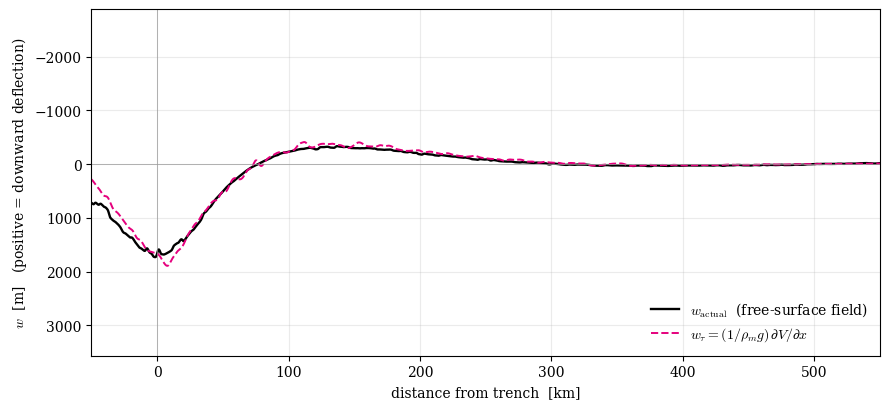

In [16]:
from scipy.ndimage import gaussian_filter1d

# Smooth V before differentiating to clean up grid-scale noise.
# σ in grid points; with DX = 1 km, σ = 10 means 10 km smoothing.
V_smooth = gaussian_filter1d(V, sigma=10, mode="nearest")
dVdx_s   = np.gradient(V_smooth, x)


# Reference column: ~500 km seaward of the trench (regional, isostatic)
x_ref_offset_km = 500
i_ref = int(np.argmin(np.abs(x - (x_trench + SEAWARD_SIGN * x_ref_offset_km * 1000))))

# Surface deflection w(x): positive = downward deflection from the regional
# reference at i_ref.  Static-shear balance: ∂V/∂x = ρ_m g · w(x).
w_tau = dVdx_s / (rho_m * g)
w_tau = w_tau - w_tau[i_ref]

# Actual deflection from the free-surface field, top row of the grid.
w_actual = fs[0, i_ref] - fs[0, :]
w_actual = gaussian_filter1d(w_actual, sigma=3, mode="nearest")

xkm_rel = (x - x_trench) / 1000.0

fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(xkm_rel, w_actual, "k-", lw=1.7,
        label=r"$w_\mathrm{actual}$  (free-surface field)")
ax.plot(xkm_rel, w_tau, color="#E5007D", lw=1.4, ls="--",
        label=r"$w_\tau = (1/\rho_m g)\,\partial V/\partial x$")

ax.axhline(0, color="0.6", lw=0.5)
ax.axvline(0, color="0.6", lw=0.5)

ax.set_xlim(-50, x_ref_offset_km + 50)
ax.set_xlabel("distance from trench  [km]")
ax.set_ylabel(r"$w$  [m]   (positive = downward deflection)")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.25)
ax.invert_yaxis()

fig.tight_layout()

fig.savefig(figures_dir / "trench_topo_shear_vs_pressure.png",
            bbox_inches="tight", dpi=220)
plt.show()


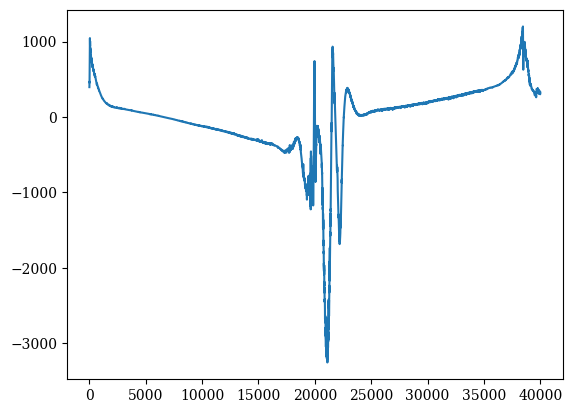

In [17]:
fig, ax = plt.subplots()

ax.plot(fs[0,:])

## 8B. First isostatic column & 4-panel column profiles

The **first isostatic column** is the first stationary point of $V$ — equivalently the first zero-crossing of $\partial V/\partial x$ — seaward of the trench. We use it as the trailing-plate anchor for the column-difference figure that follows.



In [18]:

# Find first isostatic column: first column going seaward from the trench where
# the free surface has recovered to its regional (undeflected) level.
# After x-mirror, "seaward" = increasing x = higher index (trailing plate is on the right).

BUFFER_KM    = 30
WINDOW_KM    = 500
SMOOTH_KM    = 5      # light smoothing on the surface

# Regional-reference column, 500 km seaward of the trench
i_far = int(np.argmin(np.abs(x - (x_trench + SEAWARD_SIGN * 500e3))))
h_rel = fs[0, :] - fs[0, i_far]

sigma_grid = max(1, int(SMOOTH_KM * 1000.0 / DX))
h_smooth   = gaussian_filter1d(h_rel, sigma=sigma_grid, mode="nearest")

buffer_grid = int(BUFFER_KM * 1000.0 / DX)
window_grid = int(WINDOW_KM * 1000.0 / DX)

# Walk seaward from the trench (with buffer) and stop where the surface has
# returned to or above regional (h_rel >= 0).  SEAWARD_SIGN sets the direction.
i_start = tindx + SEAWARD_SIGN * buffer_grid
i_end   = tindx + SEAWARD_SIGN * window_grid
i_start = max(0, min(len(x)-1, i_start))
i_end   = max(0, min(len(x)-1, i_end))
step    = SEAWARD_SIGN

xi_indx = None
for i in range(i_start, i_end, step):
    if h_smooth[i] >= 0.0:
        xi_indx = i
        break

if xi_indx is None:
    xi_indx     = i_end
    pick_method = "fallback: end of search window (no topo recovery found)"
else:
    pick_method = f"first topo recovery seaward of trench  (buffer={BUFFER_KM} km, smooth={SMOOTH_KM} km)"

xi_loc  = float(x[xi_indx])
#xm_loc  = 0.5 * (x_trench + xi_loc)
#xm_indx = int(np.argmin(np.abs(x - xm_loc)))

# x_M: maximum-bending-moment location.  First zero-crossing of V(x) seaward                                                                                            
# of the trench, where V(x) = ∫₀^{z_c} τ_zx dz.  Use V_smooth if it's already
# in scope (single-step §7 computes it); otherwise smooth on the fly so a                                                                                               
# noise spike near zero can't pose as a real crossing.                                                                                                                  
try:                                                                                                                                                                    
    V_for_xm = V_smooth                                                                                                                                                 
except NameError:                                                                                                                                                       
    from scipy.ndimage import gaussian_filter1d
    V_x      = np.trapz(txz, z, axis=0)                                                                                                                                 
    V_for_xm = gaussian_filter1d(V_x, sigma=10, mode='nearest')                                                                                                         

XM_BUFFER_KM = 5                                                                                                                                                        
buffer_m = XM_BUFFER_KM * 1000.0                          
seaward = (x > x_trench + buffer_m) if SEAWARD_SIGN > 0 else (x < x_trench - buffer_m)                                                                                          
                                                                                                                                                                        
xs, Vs = x[seaward], V_for_xm[seaward]                                                                                                                                  
if SEAWARD_SIGN < 0:                                                                                                                                                    
    xs, Vs = xs[::-1], Vs[::-1]                           
                                                                                                                                                                        
cross = np.where(Vs[:-1] * Vs[1:] < 0)[0]
if cross.size > 0:                                                                                                                                                      
    k = cross[0]                                          
    xm_loc = float(xs[k] - Vs[k] * (xs[k+1] - xs[k]) / (Vs[k+1] - Vs[k]))
else:                                                                                                                                                                   
    xm_loc = 0.5 * (x_trench + xi_loc)
    print("⚠  no V=0 crossing seaward of trench; falling back to (x_T + x_I)/2")                                                                                        
                                                          
xm_indx = int(np.argmin(np.abs(x - xm_loc)))   



w_T = float(fs[0, xi_indx] - fs[0, tindx])

print(f"x_T = {x_trench/1e3:8.1f} km  (tindx  = {tindx})")
print(f"x_I = {xi_loc/1e3:8.1f} km  (xi_indx = {xi_indx},  delta = {(xi_loc - x_trench)/1e3:+7.1f} km)")
print(f"x_m = {xm_loc/1e3:8.1f} km  (xm_indx = {xm_indx},  delta = {(xm_loc - x_trench)/1e3:+7.1f} km)")
print()
print(f"fs[0, tindx]   = {fs[0, tindx]:+9.1f} m")
print(f"fs[0, xi_indx] = {fs[0, xi_indx]:+9.1f} m")
print(f"w_T = fs[0, xi_indx] - fs[0, tindx] = {w_T:+.1f} m")
print(f"method: {pick_method}")


x_T =   4440.5 km  (tindx  = 22202)
x_I =   4517.3 km  (xi_indx = 22586,  delta =   +76.8 km)
x_m =   4459.4 km  (xm_indx = 22296,  delta =   +18.9 km)

fs[0, tindx]   =   -1635.1 m
fs[0, xi_indx] =     +50.1 m
w_T = fs[0, xi_indx] - fs[0, tindx] = +1685.2 m
method: first topo recovery seaward of trench  (buffer=30 km, smooth=5 km)


/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_97740/2447799373.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


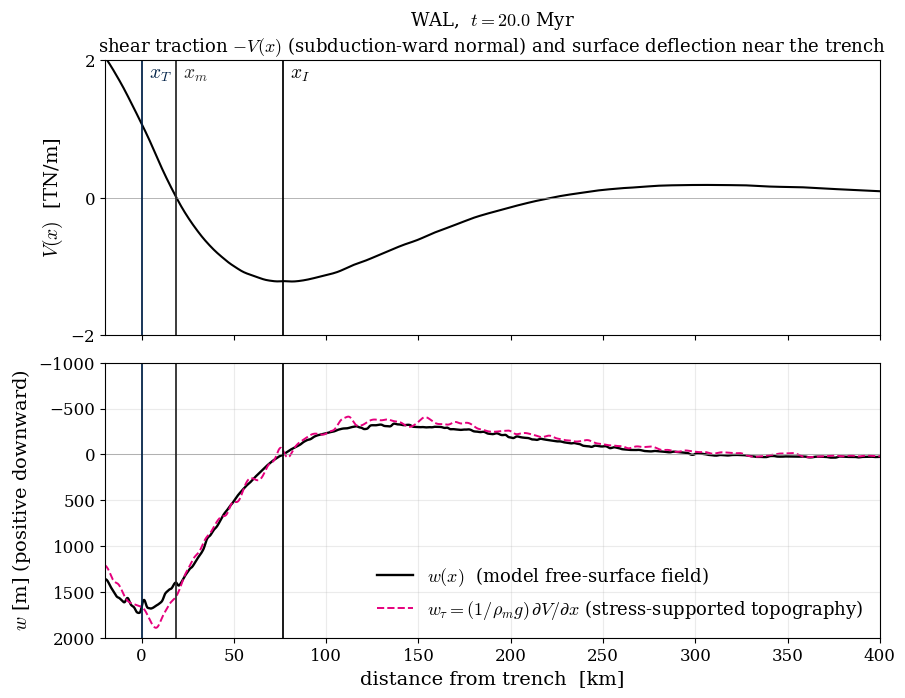

In [19]:
# Top:  shear traction -V(x) on a vertical plane with subduction-ward normal
# Bot:  surface deflection w(x) — model free-surface vs shear-derived
# Both panels plotted against the same x-coordinate (xkm_rel); no masks.



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True,
                               gridspec_kw=dict(hspace=0.10))

# --- top: V(x) -----------------------------------------------------------
ax1.plot(xkm_rel, -V_smooth * 1e-12, "k-", lw=1.5)
ax1.axhline(0, color="0.6", lw=0.5)
ax1.set_ylabel(r"$V(x)$  [TN/m]", fontsize=14)

ax1.set_yticks([-4, -2, 0, 2, 4])
ax1.tick_params(labelsize=12)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"
              f"shear traction $-V(x)$ (subduction-ward normal) "
              f"and surface deflection near the trench",
              fontsize=13)

ax1.set_ylim(-2, 2)

# --- bot: surface deflection — both curves on the same xkm_rel, no mask --
ax2.plot(xkm_rel, w_actual, "k-", lw=1.7,
         label=r"$w(x)$  (model free-surface field)")
ax2.plot(xkm_rel, w_tau, color="#E5007D", lw=1.4, ls="--",
         label=r"$w_\tau = (1/\rho_m g)\,\partial V/\partial x$ (stress-supported topography)")
ax2.axhline(0, color="0.6", lw=0.5)
ax2.set_xlabel("distance from trench  [km]", fontsize=14)
ax2.set_ylabel(r"$w$ [m] (positive downward)", fontsize=14)
ax2.legend(frameon=False, loc="lower right", fontsize=13)
ax2.tick_params(labelsize=12)
ax2.grid(alpha=0.25)
ax2.set_ylim(-1000, 2000)
ax2.invert_yaxis()

# Column lines on both panels.  Labels at top of ax1, offset right of each line.
columns = [
    (x_trench,       r"$x_T$",  "#002147"),
    (xi_loc,     r"$x_I$",  "k"),
    (x[xm_indx], r"$x_m$",  "0.15"),
]
for x_col, label, color in columns:
    xrel = (x_col - x_trench) * 1e-3
    for ax_ in (ax1, ax2):
        ax_.axvline(xrel, color=color, lw=1.4, alpha=0.9)
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),
                 xytext=(5, -4), textcoords="offset points",
                 ha="left", va="top", color=color,
                 fontsize=14, fontweight="bold")

# Trench-anchored window — x_T = 0 stays visible at every timestep
ax1.set_xlim(-20, 400)

fig.tight_layout()

fig.savefig(figures_dir / f"w_actual_vs_w_tau_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()

**Interpretation**

* $V$ is **positive at the trench** (~1 TN/m): the integrated shear traction pulls the trench column down. It crosses zero near $x_m$ and reaches its minimum at the first isostatic column $x_I$ (~75 km), where $dV/dx = 0$ — no flexural support.
* The two deflection curves overlay almost perfectly: the ~1.7 km trench deflection and the outer-rise forebulge are reproduced from the shear-stress gradient alone. The trench topography is **stress-supported — non-isostatic, essentially all of it**.

### Four-panel column profiles

Mirroring `profiles.png` from `trench_pull_mdoodz/model_analysis/figures/`. Three columns are sampled: the trench column $x_T$, the first isostatic column $x_I$, and their midpoint $x_m$. Both $x_T$ and $x_I$ are smoothed over $\pm 10\;DX$ to suppress single-column noise.

- **(a)** $\sigma_{xx}-\sigma_{zz}$ at $x_m$, with twin top-axis showing $T(z)$
- **(b)** $\tau_{zx}$ at $x_m$
- **(c)** column difference $\Delta\sigma_{zz}(z) = \sigma_{zz}(x_I, z) - \sigma_{zz}(x_T, z)$. Shaded area between the curve and zero, integrated to compensation, is the trench-pull contribution. Dashed line marks the analytical scaling $-(\rho_m - \rho_w)\,g\,w_T$ (with $\rho_w = 0$ for the no-water Cerpa setup).
- **(d)** cumulative $\Delta\mathrm{GPE}^*(z) = -\!\int_0^z(\sigma_{zz}^{(I)} - \sigma_{zz}^{(T)})\,dz'$ in TN/m. Should plateau at the regional offset by compensation depth.

The Cerpa pressure is dynamic (lithostatic subtracted), but for a column **difference** the lithostatic part cancels, so $\Delta\sigma_{zz}$ from the model output is directly comparable to the analytical scaling.

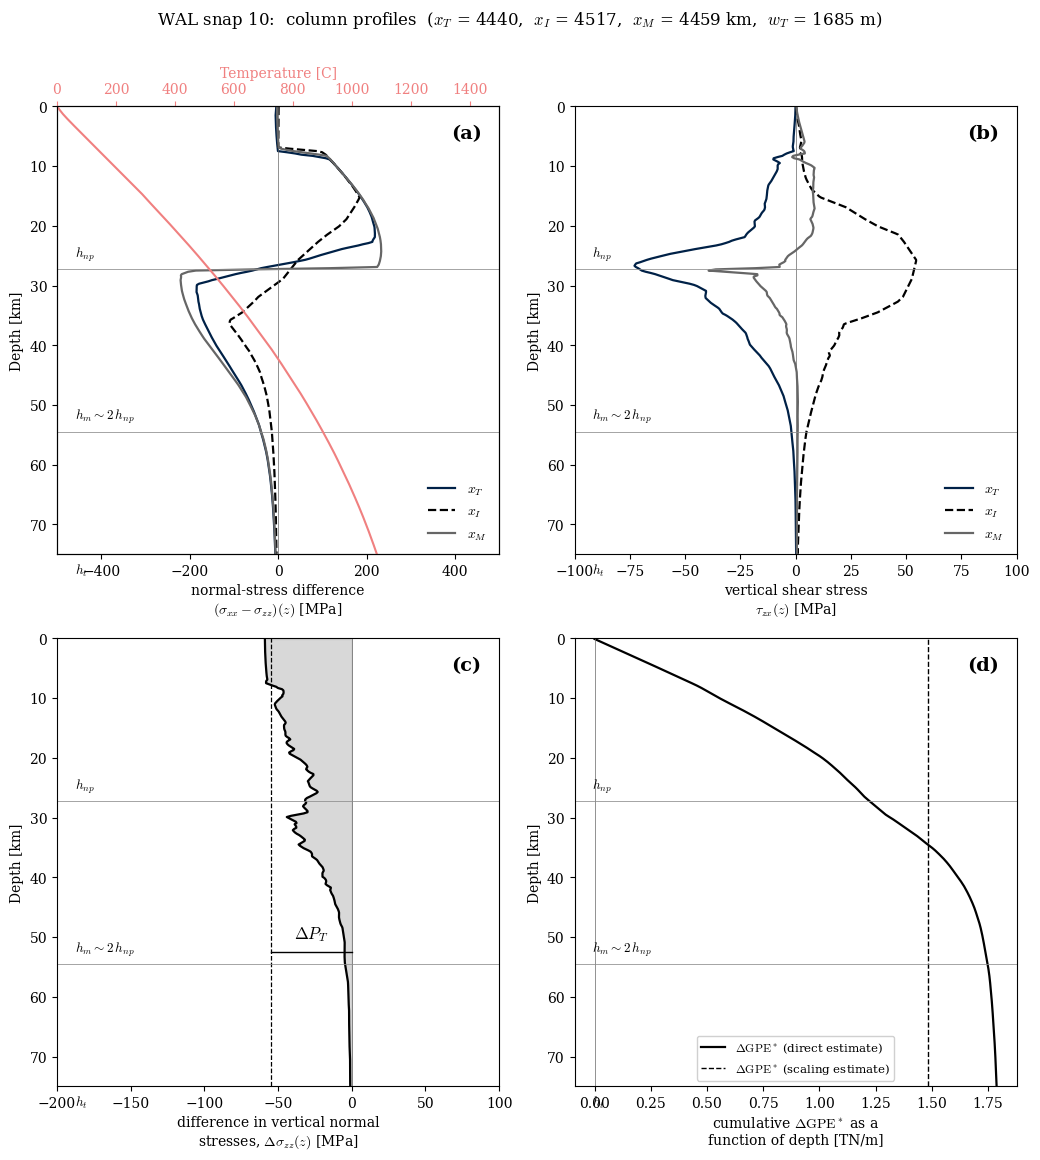

In [20]:
# 4-panel column-profile figure (mirrors trench_pull_mdoodz/profiles.png).
# No masks; domain set with xlim. w_T is the simple free-surface difference.
#
# Changes in this version:
#   - all four panels are fully framed (top/right spines kept)
#   - three column traces in (a) and (b) are differentiated by colour + linestyle,
#     with a legend; column labels switched to x_I / x_T / x_M       # was x_O                                                                                          
                                                                                                                                                                          
                                                                                                       
                                                                                                                                                                          


SMOOTHWIN = 1   # override: finer column averaging for the 4-panel column profiles

# Style for the three column traces.  x_O replaces x_I in this figure's labelling.
COL_STYLES = {                                            
      "T": dict(color="#002147", ls="-",  lw=1.6, label=r"$x_T$"),    # trench                                                                                            
      "I": dict(color="k",       ls="--", lw=1.6, label=r"$x_I$"),    # first isostatic column                                                                            
      "M": dict(color="0.4",     ls="-",  lw=1.6, label=r"$x_M$"),    # max bending moment                                                                                
}  

# sigma_zz = -p + tau_zz  (Cerpa pressure is dynamic; lithostatic part cancels in column diff)
sig_zz = -p + tzz

sig_zz_T     = col_avg(sig_zz, tindx)
sig_zz_I     = col_avg(sig_zz, xi_indx)
delta_sig_zz = sig_zz_I - sig_zz_T
delta_GPE_z  = -cumulative_trapezoid(delta_sig_zz, z, initial=0.0)

# w_T was set in the find-iso cell
delrho   = rho_m - RHO_W
ref_line = -delrho * g * w_T            # Pa (analytical Delta-sigma_zz scaling)

# Neutral plane: zero-crossing of (tau_xx - tau_zz) at x_M, between 10 and 50 km depth
diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
z_lo, z_hi = 10e3, 50e3
i_zlo = int(np.argmin(np.abs(z - z_lo)))
i_zhi = int(np.argmin(np.abs(z - z_hi)))
sc = []
for k in range(i_zlo, i_zhi):
    if diff_xm[k] * diff_xm[k+1] < 0:
        sc.append(k)
if len(sc) > 0:
    k = sc[0]
    h_np = z[k] - diff_xm[k] * (z[k+1] - z[k]) / (diff_xm[k+1] - diff_xm[k])
else:
    h_np = 30e3
h_np_km = h_np / 1e3
z_m_km  = 2 * h_np_km
z_t_km  = 80.0
gpe_est = abs(ref_line) * h_np

z_lines = [
    (h_np_km, r"$h_{np}$"),
    (z_m_km,  r"$h_m \sim 2\,h_{np}$"),
    (z_t_km,  r"$h_t$"),
]


fig, axs = plt.subplots(2, 2, figsize=(10.5, 11.5))
ax_a, ax_b = axs[0]
ax_c, ax_d = axs[1]

T_COLOR = "#F08080"

# (a) tau_xx - tau_zz  +  Temperature twin axis
ax_a.plot((txx[:, tindx]   - tzz[:, tindx])   * 1e-6, z*1e-3, **COL_STYLES["T"])
ax_a.plot((txx[:, xi_indx] - tzz[:, xi_indx]) * 1e-6, z*1e-3, **COL_STYLES["I"])
ax_a.plot((txx[:, xm_indx] - tzz[:, xm_indx]) * 1e-6, z*1e-3, **COL_STYLES["M"])
ax_a.legend(frameon=False, loc="lower right", fontsize=10)

ax_a.axvline(0, color="0.4", lw=0.5)
ax_a.set_xlim(-500, 500)
ax_a.set_ylim(*DEPTH_LIM)
ax_a.set_ylabel("Depth [km]")
ax_a.set_xlabel("normal-stress difference\n" + r"$(\sigma_{xx} - \sigma_{zz})(z)$ [MPa]")
ax_aT = ax_a.twiny()
ax_aT.plot(T[:, xm_indx] - 273, z*1e-3, color=T_COLOR, lw=1.5)
ax_aT.set_xlim(0, 1500)
ax_aT.set_xlabel("Temperature [C]", color=T_COLOR)
ax_aT.tick_params(axis="x", colors=T_COLOR)

# (b) tau_zx at the three columns
ax_b.plot(txz[:, tindx]   * 1e-6, z*1e-3, **COL_STYLES["T"])
ax_b.plot(txz[:, xi_indx] * 1e-6, z*1e-3, **COL_STYLES["I"])
ax_b.plot(txz[:, xm_indx] * 1e-6, z*1e-3, **COL_STYLES["M"])
ax_b.legend(frameon=False, loc="lower right", fontsize=10)
ax_b.axvline(0, color="0.4", lw=0.5)
ax_b.set_xlim(-100, 100)
ax_b.set_ylim(*DEPTH_LIM)
ax_b.set_ylabel("Depth [km]")
ax_b.set_xlabel("vertical shear stress\n" + r"$\tau_{zx}(z)$ [MPa]")

# (c) Delta sigma_zz column difference
ax_c.plot(delta_sig_zz * 1e-6, z*1e-3, "k-", lw=1.6)
ax_c.fill_betweenx(z*1e-3, 0, delta_sig_zz * 1e-6,
                   where=(delta_sig_zz < 0), color="0.7", alpha=0.5)
ax_c.axvline(0, color="0.4", lw=0.5)
ax_c.axvline(ref_line * 1e-6, color="k", ls="--", lw=0.9)
ax_c.set_xlim(-200, 100)
ax_c.set_ylim(*DEPTH_LIM)
ax_c.set_ylabel("Depth [km]")
ax_c.set_xlabel("difference in vertical normal\n" + r"stresses, $\Delta\sigma_{zz}(z)$ [MPa]")
z_lab = z_m_km - 2
ax_c.plot([ref_line * 1e-6, 0], [z_lab, z_lab], "k-", lw=1.0)
ax_c.text(0.5 * ref_line * 1e-6, z_lab - 1.5, r"$\Delta P_T$",
          ha="center", va="bottom", fontsize=12)

# (d) cumulative \Delta\mathrm{GPE}^*
ax_d.plot(delta_GPE_z * 1e-12, z*1e-3, "k-", lw=1.6,
          label=r"$\Delta\mathrm{GPE}^*$ (direct estimate)")
ax_d.axvline(0, color="0.4", lw=0.5)
ax_d.axvline(gpe_est * 1e-12, color="k", ls="--", lw=1.0,
             label=r"$\Delta\mathrm{GPE}^*$ (scaling estimate)")
ax_d.set_ylim(*DEPTH_LIM)
ax_d.set_ylabel("Depth [km]")
ax_d.set_xlabel("cumulative $\\Delta\\mathrm{GPE}^*$ as a\nfunction of depth [TN/m]")
ax_d.legend(loc="lower center", frameon=True, fontsize=8.5, framealpha=0.92)

# Panel labels and z'-depth guides — all four panels are kept fully framed
panel_labels = [(ax_a, "(a)"), (ax_b, "(b)"), (ax_c, "(c)"), (ax_d, "(d)")]
for ax_, lbl in panel_labels:
    ax_.text(0.96, 0.96, lbl, transform=ax_.transAxes, ha="right", va="top",
             fontsize=14, fontweight="bold")
    for zz, _ in z_lines:
        ax_.axhline(zz, color="0.55", lw=0.55)
    xlo, xhi = ax_.get_xlim()
    for zz, lbl_z in z_lines:
        ax_.text(xlo + 0.04*(xhi - xlo), zz - 1.0, lbl_z,
                 ha="left", va="bottom", fontsize=9.5)

fig.suptitle(f"{MODEL_KEY} snap {TIMESTEP_INDEX}:  column profiles  "                                                                                                   
               f"($x_T$ = {x_trench/1e3:.0f},  $x_I$ = {xi_loc/1e3:.0f},  $x_M$ = {x[xm_indx]/1e3:.0f} km,  $w_T$ = {w_T:.0f} m)",
               y=1.005) 
fig.tight_layout()

fig.savefig(figures_dir / f"profiles_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=200)
plt.show()


**Interpretation**

* Panel (a) shows the flexural signature: $\sigma_{xx}-\sigma_{zz}$ changes sign across the neutral plane $h_{np}$ — extension-like above, compression-like below at the trench column. This is why the *resultant* $N_D$ alone understates what the column is doing.
* Panel (c) is the trench pull made visible: the between-column difference $\Delta\sigma_{zz}(z)$ is finite through the strong lithosphere and **equilibrates by about $h_m \sim 2h_{np}$** — the shaded area is the trench pull force, and the dashed line marks the $\Delta P_T$ scaling.
* Panel (d): the cumulative integral plateaus by the equilibration depth, close to the scaling estimate — the direct and analytical routes to the trench pull agree.

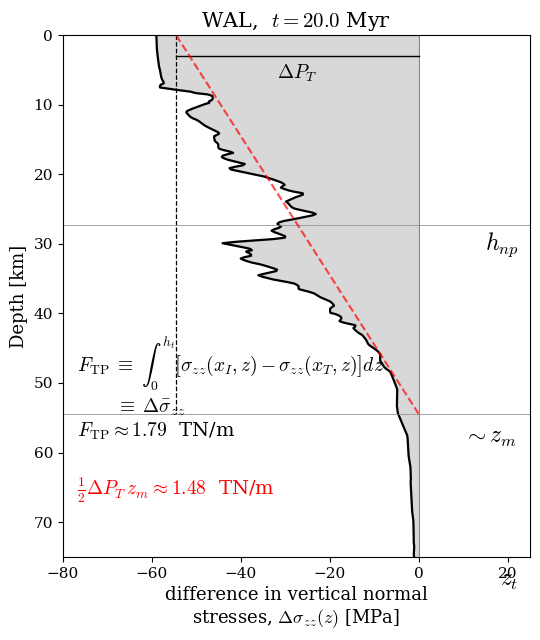

In [21]:
# Standalone panel (c) — Δσ_zz that defines the trench pull force.
# Faithful copy of panel (c) from the 4-panel figure (with ΔP_T dashed line,
# bracket, and h_np / h_m / h_t horizontal markers preserved), plus three
# extra annotations for the talk slide:
#   - lower-left equation box, including the bar-averaged form
#   - upper-right column-definitions box
#   - shading limited to the integration depth (visualises the integral)


# --- Recompute the column quantities --------------------------------------
sig_zz       = -p + tzz
sig_zz_T     = col_avg(sig_zz, tindx,   win=SMOOTHWIN)
sig_zz_I     = col_avg(sig_zz, xi_indx, win=SMOOTHWIN)
delta_sig_zz = sig_zz_I - sig_zz_T

# Analytical Δσ_zz scaling at compensation depth (the trench-pressure deficit ΔP_T)
delrho   = rho_m - RHO_W
ref_line = -delrho * g * w_T

# Neutral plane h_np, mechanical thickness h_m ≈ 2 h_np, compensation h_t
diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
i_zlo, i_zhi = int(np.argmin(np.abs(z - 10e3))), int(np.argmin(np.abs(z - 50e3)))
sc = [k for k in range(i_zlo, i_zhi) if diff_xm[k] * diff_xm[k+1] < 0]
h_np    = (z[sc[0]] - diff_xm[sc[0]] * (z[sc[0]+1] - z[sc[0]]) /
           (diff_xm[sc[0]+1] - diff_xm[sc[0]])) if sc else 30e3
h_np_km = h_np / 1e3
z_m_km  = 2 * h_np_km
z_t_km  = INTEGRATION_DEPTH_KM

z_lines = [
    (h_np_km, r"$h_{np}$"),
    (z_m_km,  r"$\sim z_m$ "),
    (z_t_km,  r"$z_t$"),
]

# Trench pull force from the direct integral, plus the bar-averaged form
i_zt    = int(np.argmin(np.abs(z - z_t_km * 1e3)))
F_TP    = -np.trapz(delta_sig_zz[:i_zt+1], z[:i_zt+1])
F_TP_TN = F_TP * 1e-12
F_TP_SR = 1e-12*(-ref_line*1e3*z_m_km*1/2)

# --- Figure ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 6.5))

ax.plot(delta_sig_zz * 1e-6, z*1e-3, "k-", lw=1.6)

# Shading limited to the integration depth so the shaded area visually IS F_TP
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_sig_zz[:i_zt+1] * 1e-6,
                 where=(delta_sig_zz[:i_zt+1] < 0), color="0.7", alpha=0.5)

# Zero reference and the ΔP_T scaling line (analytical Δσ_zz at compensation)
ax.axvline(0, color="0.4", lw=0.5)
#ax.axvline(ref_line * 1e-6,  color="k", ls="--", lw=0.9)
ax.plot([ref_line * 1e-6, ref_line * 1e-6], [0, z_m_km],                                                                                                                                             
          color="k", ls="--", lw=0.9)  

ax.set_xlim(-80, 25)
ax.set_ylim(*DEPTH_LIM)
ax.set_xlabel("difference in vertical normal\n"
              + r"stresses, $\Delta\sigma_{zz}(z)$ [MPa]", fontsize=13)
ax.set_ylabel("Depth [km]", fontsize=13)
ax.tick_params(labelsize=11)

# ΔP_T bracket and label (horizontal connector at z_lab between -ΔP_T and 0)

z_lab = 3.0                                                                                                                                                                                         
ax.plot([ref_line * 1e-6, 0], [z_lab, z_lab], "k-", lw=1.0)
ax.text(0.5 * ref_line * 1e-6, z_lab + 4, r"$\Delta P_T$",                                                                                                                                         
          ha="center", va="bottom", fontsize=14) 

# Horizontal markers and labels at h_np, h_m, h_t
xlo, xhi = ax.get_xlim()                   
for zz, lbl_z in z_lines:
    ax.axhline(zz, color="0.55", lw=0.55)                                                                                                                                                            
    ax.text(xhi - 0.025*(xhi - xlo), zz + 5.0, lbl_z,                                                                                                                                                 
              ha="right", va="bottom", fontsize=17)

# --- Equation box (lower-left) — integral AND bar-averaged form ----------
eq_text = (                                                                                                                                                                                          
    r"$F_\mathrm{TP}\;\equiv\;\int_0^{h_t}"
    r"\left[\sigma_{zz}(x_I,z) - \sigma_{zz}(x_T,z)\right] dz$"                                                                                                                                      
    "\n"                                                  
    r"$\quad\quad\;\equiv\;\Delta\bar\sigma_{zz}$"                                                                                                                                                   
    f"\n$F_\\mathrm{{TP}} \\approx {F_TP_TN:.2f}$  TN/m"                                                                                                                                             
)                                                                                                                                                                                                    
ax.text(0.03, 0.22, eq_text, transform=ax.transAxes,                                                                                                                                                 
        fontsize=14, ha="left", va="bottom")
                                                                                                                                                                                                     
# Scaling-relation line — red, placed just above the equation box                                                                                                                                    
ax.text(0.03, 0.1,
        rf"$\frac{{1}}{{2}}\Delta P_T\,z_m \approx {F_TP_SR:.2f}$  TN/m",                                                                                                                           
        transform=ax.transAxes, color="red",                                                                                                                                                         
        fontsize=14, ha="left", va="bottom")


# --- Column-definitions box (upper-right) --------------------------------
#ax.text(
#    0.97, 0.97,
#    r"$x_T$ : trench column" + "\n"
#    r"$x_I$ : first isostatic column",
#    transform=ax.transAxes,
#    fontsize=10, va="top", ha="right",
#    bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
#              edgecolor="0.7", lw=0.6, alpha=0.95),
#)

ax.plot([ref_line*1e-6 , 0], 
        [0, z_m_km], c = "r", ls = "--", alpha = 0.7)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=15)

fig.tight_layout()

fig.savefig(figures_dir / f"trench_pull_definition_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()

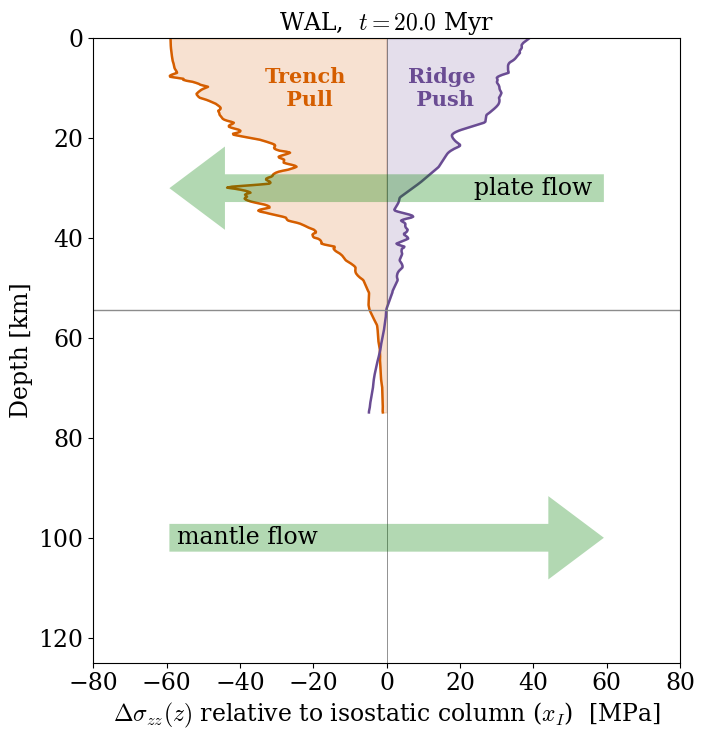

In [22]:
# Δσ_zz panel — trench-pull (left) and ridge-push (right) deltas referenced
# to the first isostatic column x_I, with two opaque arrows illustrating the
# lithospheric and asthenospheric flow directions and a "decoupling" band
# between them.
#
# delta_TP = σ_zz(x_I) - σ_zz(x_T)   (negative — left, navy)
# delta_RP = σ_zz(x_I) - σ_zz(x_R)   (positive — right, magenta)
#
# Assumes find_ridge_x is defined as a helper and SEAWARD_SIGN is in scope.

DEPTH_LIM             = (125, 0)   # override: 125 km axis for the slide figure
SMOOTHWIN             = 5           # override: sharper resolution for the slide figure
INTEGRATION_DEPTH_KM  = 150         # override: deeper integration cut-off for this view

# Decoupling band depths (km)
DECOUPLING_TOP_KM = 50
DECOUPLING_BOT_KM = 70

# Flow-illustration arrow depths (km)
LITHO_ARROW_Z_KM = 30
ASTH_ARROW_Z_KM  = 100

# Curve colours
COLOR_TP = "#002147"   # navy   — trench-pull side
COLOR_RP = "#E5007D"   # magenta — ridge-push side

COLOR_TP = "#D55E00"                                                                                              
COLOR_RP =  "#6A4C93"                                                                                                            
                                                             

# --- Locate the ridge ----------------------------------------------------
ridge_loc, ridge_indx = find_ridge_x(
    x, fs[0, :], x_trench, seaward_sign=SEAWARD_SIGN,
    buffer_km=200, smooth_km=50,
)

# --- Column averages of σ_zz at the three reference columns --------------
sig_zz   = -p + tzz
sig_zz_T = col_avg(sig_zz, tindx,     win=SMOOTHWIN)
sig_zz_I = col_avg(sig_zz, xi_indx,   win=SMOOTHWIN)
sig_zz_R = col_avg(sig_zz, ridge_indx, win=SMOOTHWIN)

delta_TP = sig_zz_I - sig_zz_T            # < 0   trench column lighter
delta_RP = sig_zz_I - sig_zz_R            # > 0   ridge  column heavier

i_zt = int(np.argmin(np.abs(z - INTEGRATION_DEPTH_KM * 1e3)))

# --- Figure --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7.5))

# Decoupling band — sits behind everything else


#ax.axhspan(DECOUPLING_TOP_KM, DECOUPLING_BOT_KM,
#           color="0.85", alpha=0.6, zorder=0)
#ax.text(78, 0.5 * (DECOUPLING_TOP_KM + DECOUPLING_BOT_KM),
#        "decoupling", ha="right", va="center",
#        fontsize=11, color="0.3", style="italic", zorder=1)

# Trench-pull lobe (negative, navy)
ax.plot(delta_TP * 1e-6, z * 1e-3, color=COLOR_TP, lw=1.8)
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_TP[:i_zt+1] * 1e-6,
                 where=(delta_TP[:i_zt+1] < 0),
                 color=COLOR_TP, alpha=0.18)

# Ridge-push lobe (positive, magenta)


ax.plot(delta_RP * 1e-6, z * 1e-3, color=COLOR_RP, lw=1.8)
#ax.plot(delta_RP * 1e-6 + 10, z * 1e-3, color=COLOR_RP, lw=1.8, ls= "--")
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_RP[:i_zt+1] * 1e-6,
                 where=(delta_RP[:i_zt+1] > 0),
                 color=COLOR_RP, alpha=0.18)

ax.axvline(0, color="0.4", lw=0.5)

ARROW_KW = dict(                                                                                                                                                                                       
      arrowstyle="simple,head_length=1.0,head_width=1.5,tail_width=0.5",
      color="green", lw=0, alpha=0.3, mutation_scale=40,                                                                                                                                                 
  )

# Lithospheric flow — left                                                                                                                                                                             
ax.annotate("", xy=(-60, LITHO_ARROW_Z_KM), xytext=(60, LITHO_ARROW_Z_KM),
              arrowprops=ARROW_KW, zorder=10)                                                                                                                                                            
                                                            
# Asthenospheric counter-flow — right                                                                                                                                                                  
ax.annotate("", xy=(60, ASTH_ARROW_Z_KM), xytext=(-60, ASTH_ARROW_Z_KM),
              arrowprops=ARROW_KW, zorder=10) 


#ax.axhline(h_np_km, color="0.55", lw=0.55) 
ax.axhline(z_m_km, color="0.55", lw=1) 

# Region labels — sit inside their respective lobes                                                                                                                                                    
ax.text( 15, 10, "Ridge\n Push",                                                                                                                                                                        
         color=COLOR_RP, fontsize=15, fontweight="bold",                                                                                                                                               
         ha="center", va="center", zorder=11)                                                                                                                                                          
ax.text(-22, 10, "Trench\n Pull",                          
         color=COLOR_TP, fontsize=15, fontweight="bold",                                                                                                                                               
         ha="center", va="center", zorder=11)                                                                                                                                                          

# Flow labels — caption the two arrows                                                                                                                                                                 
ax.text(40, LITHO_ARROW_Z_KM , "plate flow",                             
        color="black", fontsize=17,                                                                                                                                                 
        ha="center", va="center", zorder=11)
ax.text(-38, ASTH_ARROW_Z_KM, "mantle flow",                                                                                                                                                                         
          color="black", fontsize=17,    
          ha="center", va="center", zorder=11)   


ax.set_xlim(-80, 80)
ax.set_ylim(*DEPTH_LIM)
ax.set_xlabel(r"$\Delta\sigma_{zz}(z)$ relative to isostatic column ($x_I$)  [MPa]", fontsize=17)
ax.set_ylabel("Depth [km]", fontsize=17)
ax.tick_params(labelsize=17)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=17)

fig.tight_layout()
fig.savefig(figures_dir / f"trench_ridge_delta_sigma_zz_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
              bbox_inches="tight", dpi=220) 

plt.show()

## 8C. Sub-plate pressure gradient — equilibration is good, not perfect

The narrative claim this section supports: columns largely equilibrate below the strong lithosphere, but not exactly — a systematic sub-plate pressure gradient exists, and it is much smaller than the pressure gradients due to trench topography or ridge push.


## Observation

As the integration depth `z_c` is taken progressively deeper, a systematic and persistent pressure offset emerges between the column beneath the ridge and the isostatic column of the trench. The offset asymptotes to a roughly constant value or 10 MPa at ~ 100 km.

## Two-flows interpretation

There are **two co-existing flows**, each driven by its own horizontal pressure gradient:

1. **Lithospheric flow** — in the model frame, the subducting plate moves *toward the trench*. The pressure gradient driving this is **ridge → trench** (high to low). This is the conventional ridge-push picture, with the gradient confined to the cold, strong upper part of the lithosphere.

2. **Asthenospheric counter-flow** — mass conservation requires return flow *toward the ridge*. Driving this requires the **opposite** gradient: **trench → ridge**. The deeper, weaker asthenosphere supplies it.
.
## The cancellation problem

If the analysis is done as a single cumulative depth integral of the horizontal pressure gradient, both contributions are summed indiscriminately. The result is:

- Shallow depths only — you measure the **lithospheric** (ridge → trench) driving gradient. Sign positive in the convention here.
- Deeper integration — you start adding the **asthenospheric** (trench → ridge) gradient. Sign negative.
- Take the integral all the way through — the two contributions tend to cancel, and the integrated horizontal force on a vertical column appears to vanish.

That cancellation is real, but a misleading physical picture. It would lead a reader to conclude "nothing is driving anything", when in fact two independent driving gradients are doing real and opposing work in two depth intervals.


In [23]:
#sig_zz_I - sig_zz_R =>NEG
#P_I - P_R => positive
#
#P_R- P_I => neg (at depth_)
#consisitent with a long wavelnegtgh counterflow

In [24]:
#60e6*100e3*1e-12
#z_m_km, ref_line
F_TP * 1e-12
1e-12*(-ref_line*1e3*z_m_km*1/2)

1.4843417568949082

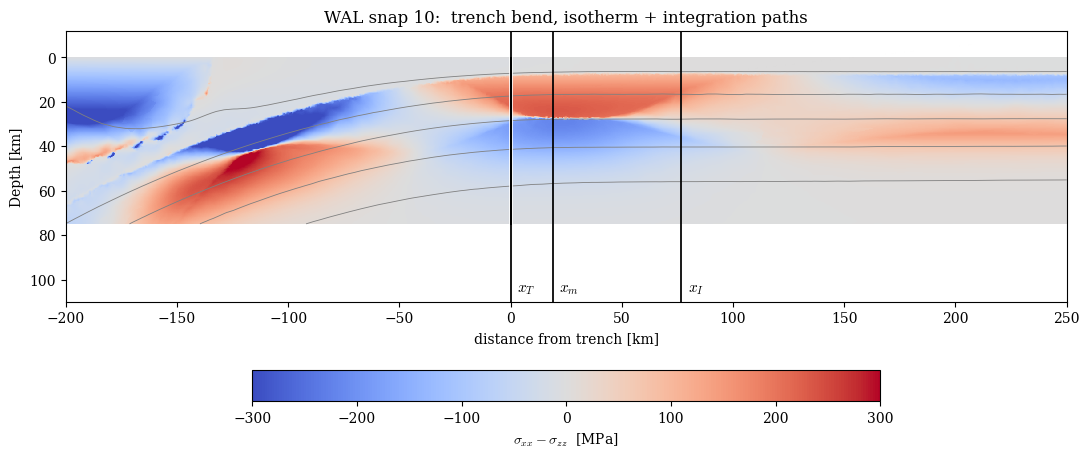

In [25]:
# Differential-stress + isotherm contours, trench-relative.  X-axis is
# distance from the trench; vertical-line labels offset 10 km to the right
# so they no longer overprint their lines.

WIN_X_KM = 200
WIN_Z_KM = 110

# Trench-relative window (km).  Trench sits at x = 0.
xkm_lo = -WIN_X_KM            # 200 km landward
xkm_hi = +250                 # 250 km seaward

# Mask in absolute coords for slicing the field arrays
ix_v = (x >= x_trench + xkm_lo * 1e3) & (x <= x_trench + xkm_hi * 1e3)

# Trench-relative x coordinate for plotting (km)
xkm_v = (x[ix_v] - x_trench) * 1e-3

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.pcolormesh(xkm_v, z*1e-3,
                   (txx[:, ix_v] - tzz[:, ix_v]) * 1e-6,    # Pa → MPa
                   cmap='coolwarm', shading='auto',
                   vmin=-300, vmax=300)

cbar = fig.colorbar(im, ax=ax,
                    label=r'$\sigma_{xx} - \sigma_{zz}$  [MPa]',
                    orientation='horizontal', fraction=0.06, pad=0.13)

ax.contour(xkm_v, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='grey', linewidths=0.6)

# Vertical integration line at the trench (now at x = 0)
ax.plot([0, 0], [z[0]*1e-3, z[-1]*1e-3], color='white', lw=2.6)
ax.plot([0, 0], [z[0]*1e-3, z[-1]*1e-3], color='black', lw=1.4)


ax.invert_yaxis()
ax.set_xlim(xkm_lo, xkm_hi)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance from trench [km]')
ax.set_ylabel('Depth [km]')
ax.set_aspect('equal')
ax.set_title(f'{MODEL_KEY} snap {TIMESTEP_INDEX}:  '
             'trench bend, isotherm + integration paths')

# Column lines: vertical lines at x_T, x_I, x_M with labels offset
# 10 km to the right (left-anchored) so they no longer sit on the line.
LABEL_OFFSET_KM = 3
columns = [
    (x_trench,         r'$x_T$',  'k'),
    (xi_loc,       r'$x_I$',  'k'),
    (x[xm_indx],   r'$x_m$',  'k'),
]
for x_col, label, color in columns:
    xrel = (x_col - x_trench) * 1e-3                          # trench-relative km
    ax.axvline(xrel, color=color, lw=1.4, alpha=0.9)
    ax.annotate(label,
                xy=(xrel + LABEL_OFFSET_KM, 0),
                xycoords=('data', 'axes fraction'),
                xytext=(0, 4), textcoords='offset points',
                ha='left', va='bottom',
                color=color, fontsize=11, fontweight='bold')

fig.tight_layout()

figures_dir = Path('../figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'ns_diff_isotherms_{MODEL_KEY}_f{TIMESTEP_INDEX}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 9. Force balance — single timestep



The dashed green curve is the residual $\Delta N_D - \Delta \mathrm{GPE}^* + F_B$ — should be small everywhere if the integrals close.


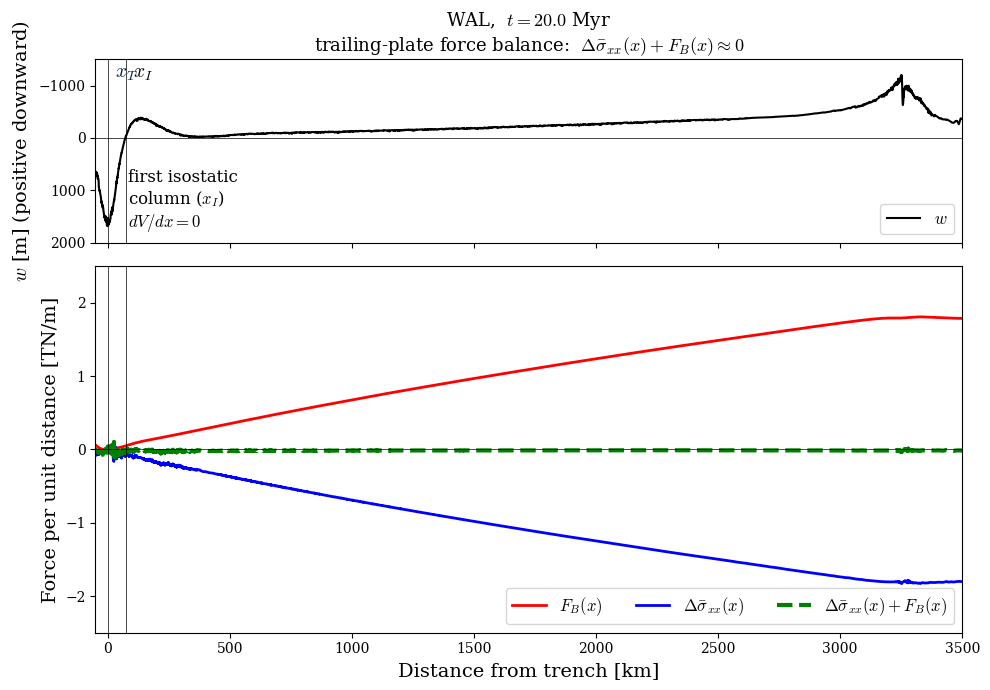

In [26]:
# § 8.1b — Boring form of the force balance, with topography panel
#                                                                                                                                                                                                    
#   Delta Sigma_xx(x) + F_B(x) ~ 0                        
#                                                                                                                                                                                                    
# Two-panel: free surface (top), boring force balance (bottom).
# In the mirrored frame, deltas are referenced to a ±N km window around x_T.                                                                                                                         
                                                                                                                                                                                                     
# Trench-reference window: average ±N km around the picked trench column.  
# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 5   # uniform ±5 km suite window (conventions §4.1)
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))
                                                                                                                                                                                                     
Sxx       = np.trapz(-p + txx, z, axis=0)              # int sigma_xx dz                                                                                                                             
delta_Sxx = Sxx - col_avg(Sxx, tindx, win=WIN_T)                                                                                                                                                     
                                                                                                                                                                                                     
xkm = (x - x_trench) * 1e-3                                   
                                                                                                                                                                                                     
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,                                                                                                                                   
                                gridspec_kw={"height_ratios": [1, 2]})
                                                                                                                                                                                                     
# --- Top: free surface (positive = downward deflection) ---                                                                                                                                   
ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,
         label="$w$")                                                                                                                                                                
                                                          
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                    
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - x_trench) * 1e-3, color="k", lw=0.5)                                                                                                                                               
ax1.set_ylim(2000, -1500)                       # inverted: deflection down +ve                                                                                                                      
ax1.set_ylabel("$w$ [m] (positive downward)", fontsize=14)
ax1.legend(loc="lower right", fontsize=12)                                                                                                                                                           
ax1.text((xi_loc - x_trench) * 1e-3 + 5, 1700,                
         "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                            
         fontsize=12)                                     
                                                                                                                                                                                                     
# x_T / x_I labels along the top of the top panel         
for x_col, label, color in [(x_trench,  r"$x_T$", "#002147"),                                                                                                                                            
                            (xi_loc, r"$x_I$", "k")]:                                                                                                                                                
    xrel = (x_col - x_trench) * 1e-3
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),                                                                                                                            
                 xytext=(5, -4), textcoords="offset points",
                 ha="left", va="top", color=color,                                                                                                                                                   
                 fontsize=14, fontweight="bold")          
                                                                                                                                                                                                     
# --- Bottom: boring form, Delta Sxx + F_B ~ 0 ---                                                                                                                                                   
ax2.plot(xkm, FB         * 1e-12, color="red", lw=2,
         label=r"$F_B(x)$")                                                                                                                                                                          
ax2.plot(xkm, delta_Sxx  * 1e-12, color="b",   lw=2,                                                                                                                                                 
         label=r"$\Delta\bar\sigma_{xx}(x)$")
ax2.plot(xkm, (delta_Sxx + FB) * 1e-12,                                                                                                                                                              
         color="g", ls="--", lw=3,                        
         label=r"$\Delta\bar\sigma_{xx}(x) + F_B(x)$")                                                                                                                                               
                                                          
ax2.axhline(0, color="k", lw=0.5)                                                                                                                                                                    
ax2.axvline(0, color="k", lw=0.5)                         
ax2.axvline((xi_loc - x_trench) * 1e-3, color="k", lw=0.5)                                                                                                                                               
ax2.set_xlabel("Distance from trench [km]", fontsize=14)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=14)                                                                                                                                        
ax2.set_xlim(-50, 3500)                                   
ax2.set_ylim(-2.5, 2.5)                                                                                                                                                                              
ax2.legend(loc="lower right", fontsize=12, ncol=3)        
                                                                                                                                                                                                     
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
              r"trailing-plate force balance:  "
              r"$\Delta\bar\sigma_{xx}(x) + F_B(x) \approx 0$",                                                                                                                                      
              fontsize=13)                                                                                                                                                                           
 
fig.tight_layout()                                                                                                                                                                                   
fig.savefig(figures_dir / f"force_balance_xx_FB_topo_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)                                                                                                                                                            
plt.show()

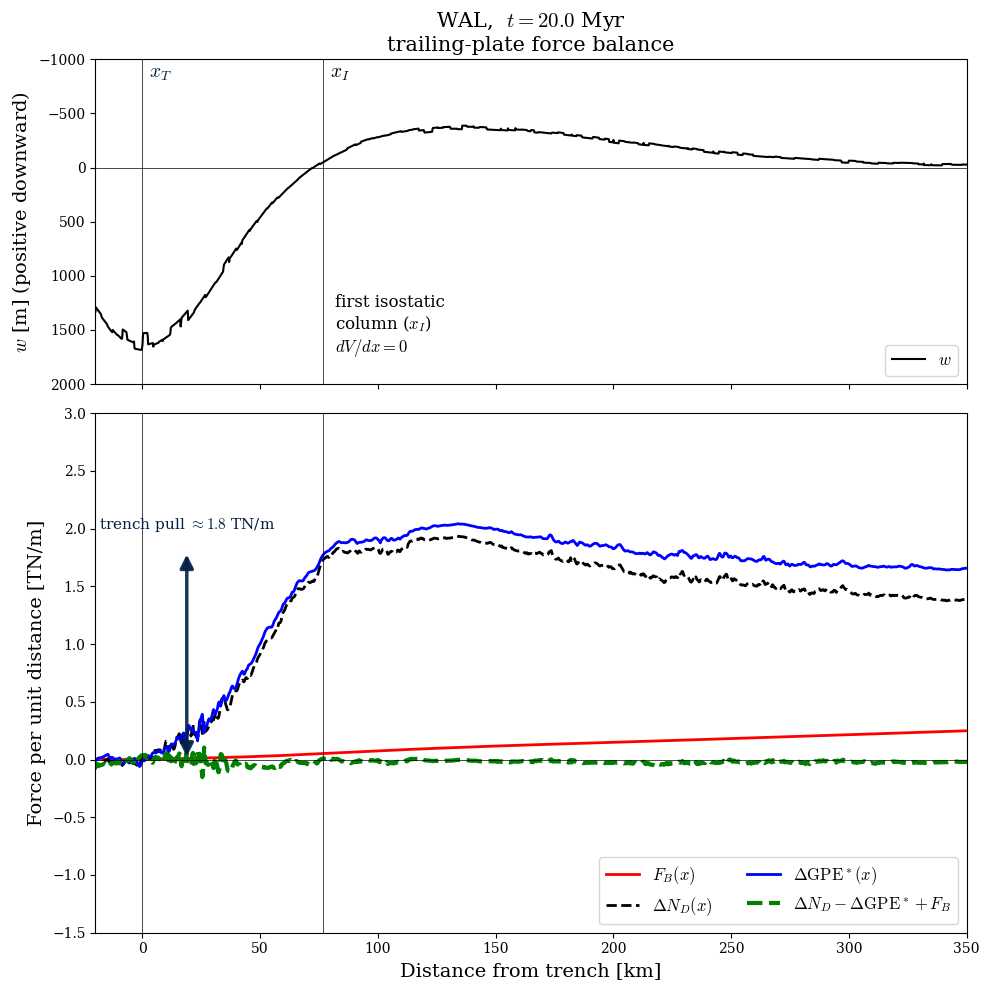

In [27]:
# § 8.2 — Interesting form of the force balance, with topography panel
#
#   Delta N_D(x) - \Delta\mathrm{GPE}^*(x) + F_B(x) ~ 0
#
# In the mirrored frame, the natural deltas are (current - trench).

Sxx = np.trapz(-p + txx, z, axis=0)     # int sigma_xx dz
Szz = np.trapz(-p + tzz, z, axis=0)     # int sigma_zz dz   (= -\mathrm{GPE}^*)

#delta_Fd  = Fd  - Fd[tindx]
#delta_Szz = Szz - Szz[tindx]            # = -\Delta\mathrm{GPE}^*  (we plot this directly)

# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 5   # uniform ±5 km suite window (conventions §4.1)
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))
                                                                                                                                                                                        
delta_Fd = Fd  -  col_avg(Fd, tindx, win=WIN_T)
GPE       = -Szz                                  # \mathrm{GPE}^*(x) = -∫σ_zz dz                                                                                                 
delta_GPE = GPE - col_avg(GPE, tindx, win=WIN_T)  # \Delta\mathrm{GPE}^*(x) 


# Pseudo-topography from V's gradient, aligned to actual at x_I
topo_actual     = fs[0, :]
topo_pseudo     = -dVdx / (rho_m * g)
topo_pseudo_ref = topo_pseudo - topo_pseudo[xi_indx] - topo_actual[xi_indx]

xkm = (x - x_trench) * 1e-3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                gridspec_kw={"height_ratios": [1.25, 2]})

# --- Top: topography ---
# --- Top: free surface (positive = downward deflection) ---                                                                                                                                 
ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,                                                                                                                                               
         label="$w$")                                                                                                                                                              
                                                                                                                                                                                                   
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                  
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - x_trench)*1e-3, color="k", lw=0.5)                                                                                                                                               
ax1.set_ylim(2000, -1000)                       # was (-2000, 1000)                                                                                                                                
ax1.set_ylabel("$w$ [m] (positive downward)", fontsize=14)
ax1.legend(loc="lower right", fontsize=12)      # ncol=2 dropped — only one curve                                                                                                                  
ax1.text((xi_loc - x_trench)*1e-3 + 5, 1700,        # was y = -1700                                                                                                                                    
           "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                          
           fontsize=12)  

# --- Bottom: \Delta N_D - \Delta\mathrm{GPE}^* + F_B ---
ax2.plot(xkm, FB         * 1e-12, color="red", lw=2,
         label=r"$F_B(x)$")
ax2.plot(xkm, delta_Fd   * 1e-12, color="k", ls="--", lw=2,
         label=r"$\Delta N_D(x)$")
ax2.plot(xkm, delta_GPE  * 1e-12, color="b", lw=2,
         label=r"$\Delta\mathrm{GPE}^*(x)$")
ax2.plot(xkm, (delta_Fd - delta_GPE + FB) * 1e-12,
         color="g", ls="--", lw=3,
         label=r"$\Delta N_D - \Delta\mathrm{GPE}^* + F_B$")

################
# Trench pull force scale: \Delta\mathrm{GPE}^* between x_T and x_I, drawn as an arrow at x_M.                                                                                                                      
TRENCH_PULL_TN = 1.8                   
xM_rel_km = (x[xm_indx] - x_trench) * 1e-3                                                                                                                                                               
ax2.annotate("", xy=(xM_rel_km, TRENCH_PULL_TN), xytext=(xM_rel_km, 0),                                                                                                                              
               arrowprops=dict(arrowstyle="<|-|>", color="#002147",                                                                                                                                      
                               lw=2.5, mutation_scale=20, alpha=0.9)) 

ax2.text(xM_rel_km, TRENCH_PULL_TN + 0.15,                                                                                                                                                           
           r"trench pull $\approx %.1f$ TN/m" % TRENCH_PULL_TN,
           color="#002147", fontsize=11, ha="center", va="bottom")
#################


ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.axvline((xi_loc - x_trench)*1e-3, color="k", lw=0.5)
ax2.set_xlabel("Distance from trench [km]", fontsize=14)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=14)
ax2.set_xlim(-20, 350)
ax2.set_ylim(-1.5, 3.0)
ax2.legend(loc="lower right", fontsize=12, ncol=2)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
                r"trailing-plate force balance"                                                                                                                                                     ,
                fontsize=15)
for x_col, label, color in [(x_trench, r"$x_T$", "#002147"),                                                                                                                                             
                              (xi_loc, r"$x_I$", "k")]:     
    xrel = (x_col - x_trench) * 1e-3                                                                                                                                                                     
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),
                   xytext=(5, -4), textcoords="offset points",                                                                                                                                         
                   ha="left", va="top", color=color,        
                   fontsize=14, fontweight="bold")

fig.savefig(figures_dir / f"force_balance_FD_GPE_FB_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",                                                                                                              
              bbox_inches="tight", dpi=220)

fig.tight_layout()
plt.show()


**Interpretation**

* The balance closes: the green sum sits on zero at every $x$. Within ~100 km of the trench, $\Delta N_D$ mirrors $\Delta\mathrm{GPE}^*$ almost exactly — $F_B$ is negligible on that wavelength, so the trench's pressure signal is absorbed by an equal-and-opposite change in the normal-stress-difference resultant.
* Over the full plate, $\Delta\mathrm{GPE}^*$ is the driving term and $F_B$ accumulates as the broad resisting term.

 ## § 9.3 — Plotting the absolute value of $N_D$   


  The previous panel shows the three-term balance                                                                                                                                                      
   
  $$\Delta N_D(x) \;-\; \Delta\mathrm{GPE}^*(x) \;+\; F_B(x) \;\approx\; 0$$                                                                                                                           
                                                                                                                                                                                                       
  with every term anchored to zero at $x_T$. That makes the *shape* of the balance easy to read, but loses the *absolute* value of $N_D$ — the quantity that has a direct physical interpretation for 
  any single column.                                                                                                                                                                                   
                                                            
  Expanding the delta operator,                                                                                                                                                                        
                                                                                                                                                                                                       
  $$\Delta N_D(x) \;=\; N_D(x) \;-\; N_D(x_T),$$
                                                                                                                                                                                                       
  and absorbing the constant $-N_D(x_T)$ into the GPE bracket gives an equivalent rearrangement:
                                                                                                                                                                                                       
  $$N_D(x) \;-\; \Big[\Delta\mathrm{GPE}^*(x) \;+\; N_D(x_T)\Big] \;+\; F_B(x) \;\approx\; 0 \;.$$
                                                                                                                                                                                                       
  Algebraically this is identical to the previous form: the same constant $N_D(x_T)$ is added to one term and subtracted from another, so the closure is unchanged. What we gain is interpretive — 
  $N_D(x)$ is now plotted at its **true value**, not relative to the trench. That value carries an objective physical meaning for any single lithospheric column:                                      
                                                            
  - $N_D(x) > 0$ — the column is **tension-like**: the depth-integrated $\sigma_{xx}-\sigma_{zz}$ acts in the $+x$ direction.                                                                              
  - $N_D(x) < 0$ — the column is **compression-like**.      
                                                                                                                                                                                                       
  Within the bending plate/slab, both senses coexist over depth (extension above the neutral plane, compression below). $N_D$ is the depth-integrated resultant, not a pointwise statement about every depth.  
                                                                                                                                                                                                       


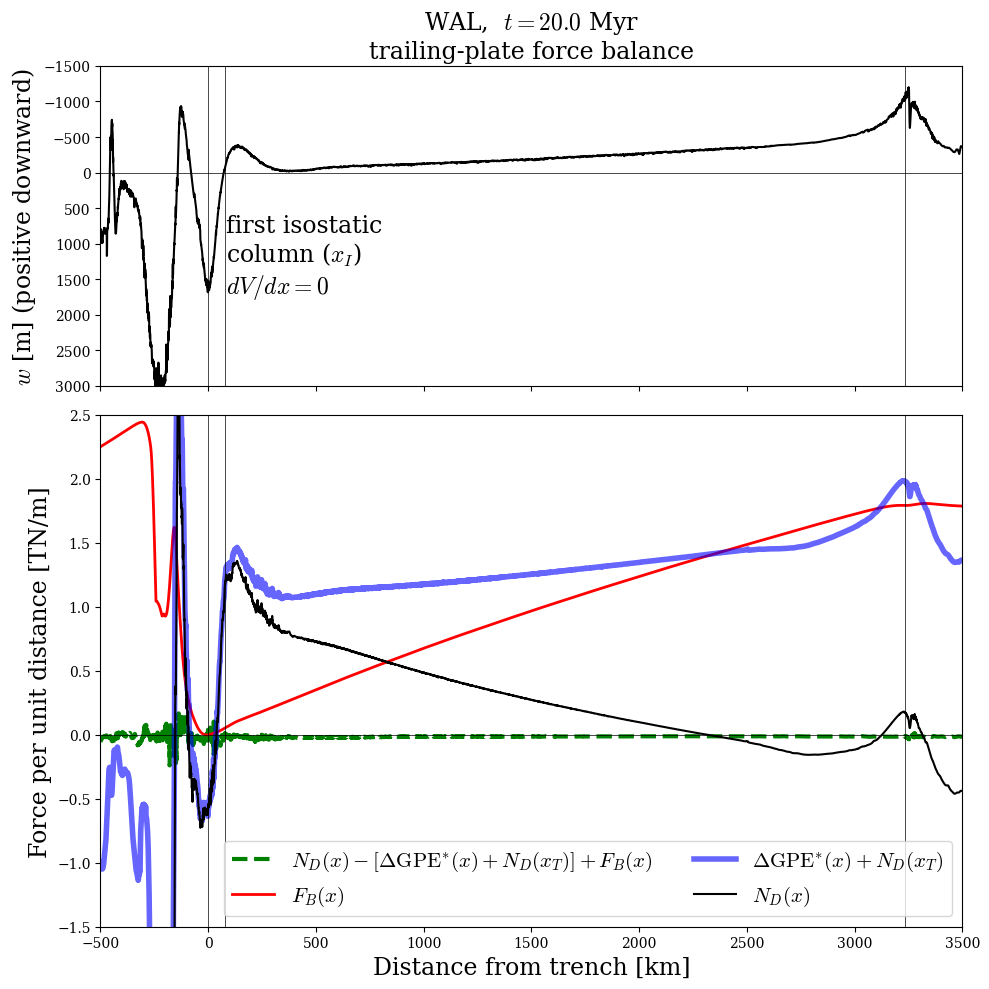

In [28]:
# § 8.2 — Interesting form of the force balance, with topography panel
#
#   Delta N_D(x) - \Delta\mathrm{GPE}^*(x) + F_B(x) ~ 0
#
# In the mirrored frame, the natural deltas are (current - trench).

Sxx = np.trapz(-p + txx, z, axis=0)     # int sigma_xx dz
Szz = np.trapz(-p + tzz, z, axis=0)     # int sigma_zz dz   (= -\mathrm{GPE}^*)
GPE       = -Szz                                  # \mathrm{GPE}^*(x) = -∫σ_zz dz                                                                                                 
delta_GPE = GPE - col_avg(GPE, tindx, win=WIN_T)  # \Delta\mathrm{GPE}^*(x)                                                                                                            
Fd_T      = col_avg(Fd, tindx, win=WIN_T)         # N_D(x_T) — scalar offset
                                                                                                                                                                          
bracket_term   = delta_GPE + Fd_T                      # the [\Delta\mathrm{GPE}^* + N_D(x_T)] block                                                                                        
residual  = Fd - bracket_term + FB                     # the §8.3 closure 



# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 5   # uniform ±5 km suite window (conventions §4.1)
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))
                                                                                                                                                                                        

# Pseudo-topography from V's gradient, aligned to actual at x_I
topo_actual     = fs[0, :]
topo_pseudo     = -dVdx / (rho_m * g)
topo_pseudo_ref = topo_pseudo - topo_pseudo[xi_indx] - topo_actual[xi_indx]

xkm = (x - x_trench) * 1e-3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                gridspec_kw={"height_ratios": [1.25, 2]})

ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,                                                                                                                                               
         label="$w$")                                                                                                                                                              
                                                                                                                                                                                                   
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                  
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - x_trench)*1e-3, color="k", lw=0.5)
ax1.axvline((rloc - x_trench)*1e-3, color="k", lw=0.5)  
ax1.set_ylim(3000, -1500)                       # was (-2000, 1000)                                                                                                                                
ax1.set_ylabel("$w$ [m] (positive downward)", fontsize=17)
#ax1.legend(loc="lower right", fontsize=17)      # ncol=2 dropped — only one curve                                                                                                                  
ax1.text((xi_loc - x_trench)*1e-3 + 5, 1700,        # was y = -1700                                                                                                                                    
           "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                          
           fontsize=17)  



ax2.plot(xkm, residual * 1e-12, color="g", ls="--", lw=3, 
         label=r"$N_D(x) - [\Delta\mathrm{GPE}^{*}(x) + N_D(x_T)] + F_B(x)$")                                                               
ax2.plot(xkm, FB       * 1e-12, color="red", lw=2, label=r"$F_B(x)$")                                                                                                                 
ax2.plot(xkm, bracket_term  * 1e-12, color="b", lw=4, alpha=0.6, label=r"$\Delta\mathrm{GPE}^{*}(x) + N_D(x_T)$")                                                                                   
ax2.plot(xkm, Fd       * 1e-12, color="k", ls="-", lw=1.5, label=r"$N_D(x)$")

ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.axvline((xi_loc - x_trench)*1e-3, color="k", lw=0.5)
ax2.axvline((rloc - x_trench)*1e-3, color="k", lw=0.5)  
ax2.set_xlabel("Distance from trench [km]", fontsize=17)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=17)
ax2.set_xlim(-500, 3500)
ax2.set_ylim(-1.5, 2.5)
ax2.legend(loc="lower right", fontsize=15, ncol=2)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
                r"trailing-plate force balance"                                                                                                                                                     ,
                fontsize=17)


#ax1.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
#ax2.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
#ax2.set_xlim(-20, 3500) 

fig.savefig(figures_dir / f"force_balance_FD_abs_GPE_FB_{MODEL_KEY}_f{TIMESTEP_INDEX}.png",                                                                                                              
              bbox_inches="tight", dpi=220)

fig.tight_layout()
plt.show()

**Interpretation**

* Same balance, but with $N_D$ at its **true value**: at this timestep $N_D(x_T)$ sits near zero-to-negative — the column beneath the trench is *not* transmitting a tension-like force from the slab; where negative, the normal-stress difference resists the trailing plate.
* The tension-like values outboard of the trench arise from balancing the trench pull, not from slab pull — the crux of the argument, opposite to the textbook paradigm.